In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

df = pd.read_csv('/home/deborah/Documentos/neuropredict/data/oasis_longitudinal.csv')

In [179]:
df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [180]:
print(df.shape)

(373, 15)


In [181]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), object(5)
memory usage: 43.8+ KB
None


In [182]:
to_drop = ['Subject ID', 'MRI ID', 'Hand']
df.drop(to_drop, inplace=True, axis=1)
df.head(25)

,Group,Visit,MR Delay,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,Nondemented,1,0,M,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,Nondemented,2,457,M,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,Demented,1,0,M,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,Demented,2,560,M,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,Demented,3,1895,M,80,12,NaN,22.0,0.5,1698,0.701,1.034
5,Nondemented,1,0,F,88,18,3.0,28.0,0.0,1215,0.710,1.444
6,Nondemented,2,538,F,90,18,3.0,27.0,0.0,1200,0.718,1.462
7,Nondemented,1,0,M,80,12,4.0,28.0,0.0,1689,0.712,1.039
8,Nondemented,2,1010,M,83,12,4.0,29.0,0.5,1701,0.711,1.032
9,Nondemented,3,1603,M,85,12,4.0,30.0,0.0,1699,0.705,1.033


In [183]:
print(df.isnull().sum())

Group        0
Visit        0
MR Delay     0
M/F          0
Age          0
EDUC         0
SES         19
MMSE         2
CDR          0
eTIV         0
nWBV         0
ASF          0
dtype: int64


In [184]:
for column in ['SES', 'MMSE']:
    df[column].fillna(df[column].median(), inplace=True)

df.head(25)

,Group,Visit,MR Delay,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,Nondemented,1,0,M,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,Nondemented,2,457,M,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,Demented,1,0,M,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,Demented,2,560,M,76,12,2.0,28.0,0.5,1738,0.713,1.010
4,Demented,3,1895,M,80,12,2.0,22.0,0.5,1698,0.701,1.034
5,Nondemented,1,0,F,88,18,3.0,28.0,0.0,1215,0.710,1.444
6,Nondemented,2,538,F,90,18,3.0,27.0,0.0,1200,0.718,1.462
7,Nondemented,1,0,M,80,12,4.0,28.0,0.0,1689,0.712,1.039
8,Nondemented,2,1010,M,83,12,4.0,29.0,0.5,1701,0.711,1.032
9,Nondemented,3,1603,M,85,12,4.0,30.0,0.0,1699,0.705,1.033


In [185]:
df.describe()

,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,77.013405,14.597855,2.436997,27.351206,0.290885,1488.128686,0.729568,1.195461
std,0.922843,635.485118,7.640957,2.876339,1.109307,3.675329,0.374557,176.139286,0.037135,0.138092
min,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000
25%,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.000000,0.700000,1.099000
50%,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.000000,0.729000,1.194000
75%,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1597.000000,0.756000,1.293000
max,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.000000,0.837000,1.587000


In [186]:
df['Group'] = df['Group'].replace('Converted', 'Demented')

contagem = df['Group'].value_counts()
print(contagem)

Group
Nondemented    190
Demented       183
Name: count, dtype: int64


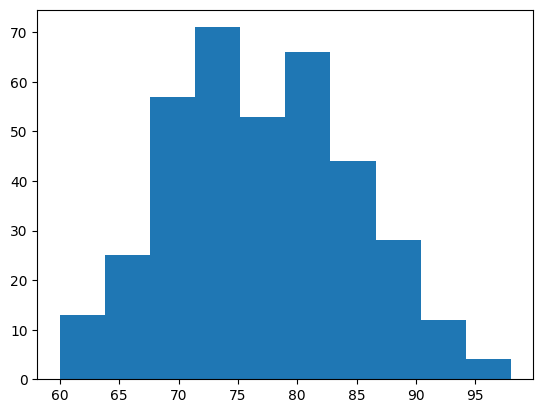

In [187]:
# ANÁLISE UNIVARIADA

df.rename(columns={'M/F' : 'Gender'}, inplace=True)

_ = plt.hist(df.Age)

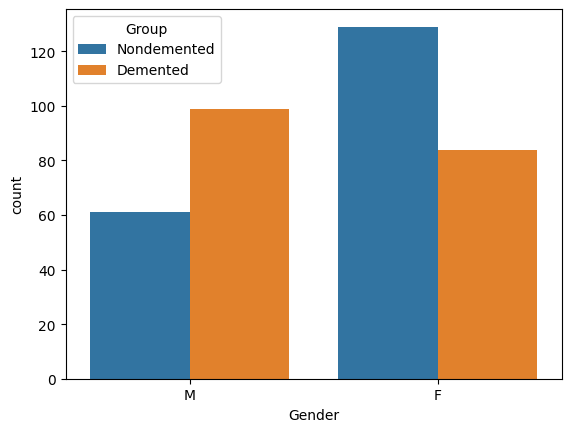

In [188]:
# ANÁLISE BIVARIADA

_ = sns.countplot(x = 'Gender', hue = 'Group', data = df)

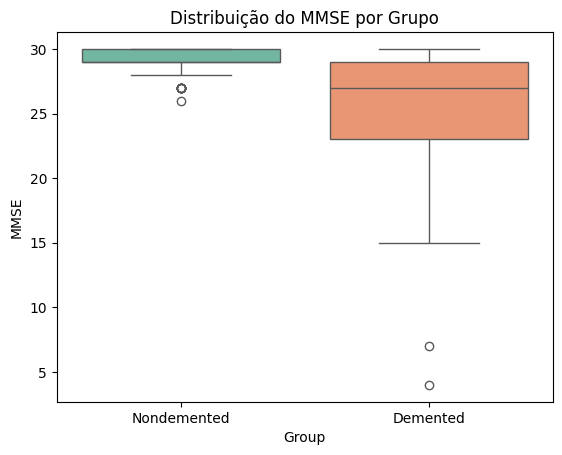

In [189]:
_ = sns.boxplot(x='Group', y='MMSE', data=df, palette='Set2')
_ = plt.title('Distribuição do MMSE por Grupo')

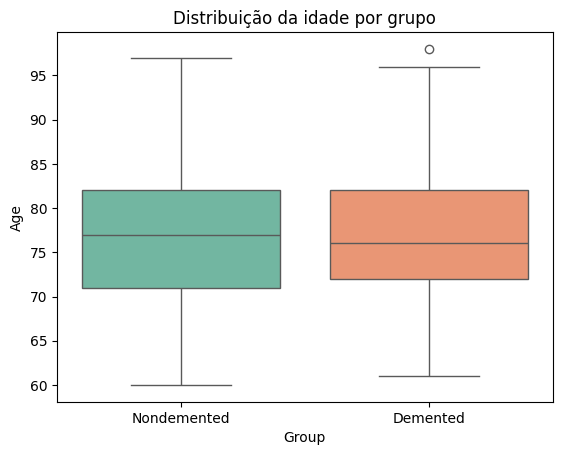

In [190]:
_ = sns.boxplot(x = 'Group', y = 'Age', data = df, palette = 'Set2')
_ = plt.title('Distribuição da idade por grupo')

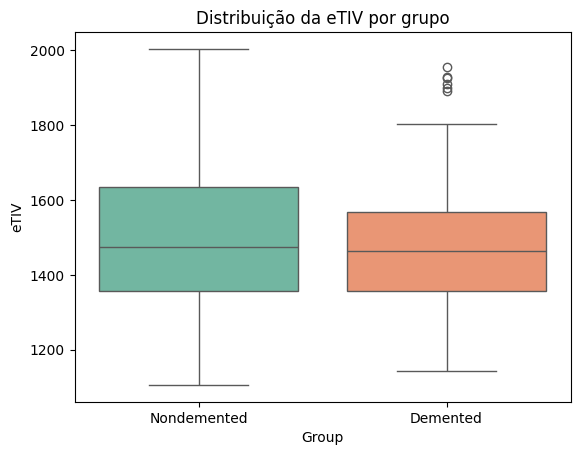

In [191]:
_ = sns.boxplot(x = 'Group', y = 'eTIV', data = df, palette = 'Set2')
_ = plt.title('Distribuição da eTIV por grupo')

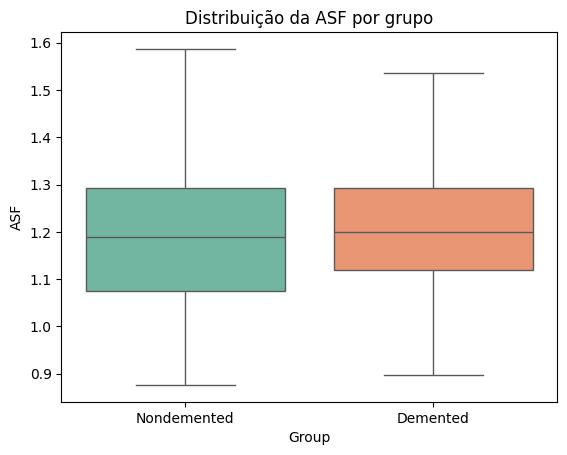

In [192]:
_ = sns.boxplot(x = 'Group', y = 'ASF', data = df, palette = 'Set2')
_ = plt.title('Distribuição da ASF por grupo')

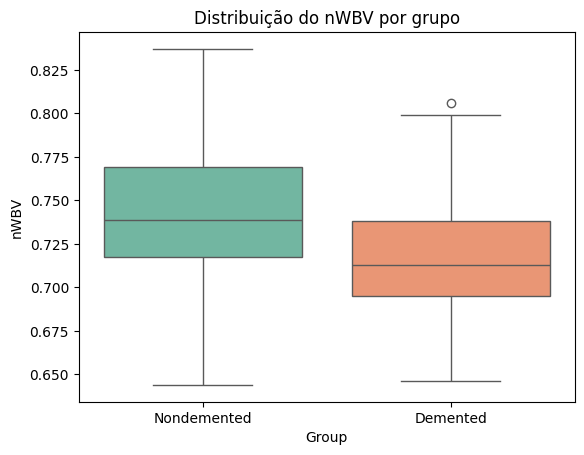

In [193]:
_ = sns.boxplot(x = 'Group', y = 'nWBV', data = df, palette = 'Set2')
_ = plt.title('Distribuição do nWBV por grupo')

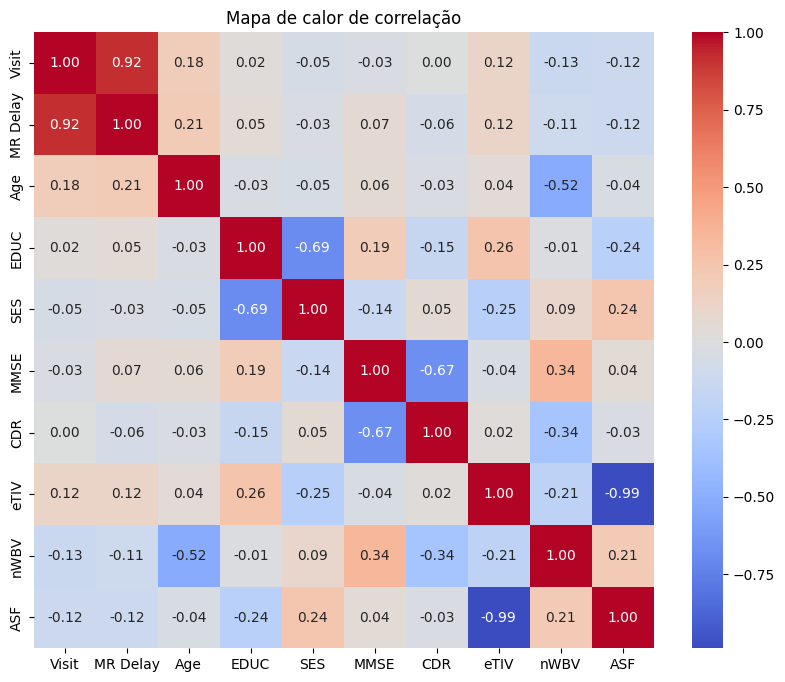

In [194]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Mapa de calor de correlação')
plt.show()

Como visto no mapa de correlação, as variáveis eTIV e ASF possuem valor de correlação altíssimo. Por conta disso, e como o ASF é usado para calcular o eTIV, há redudância ao deixar ambos os valores na tabela.

In [195]:
to_drop2 = ['ASF', 'Visit', 'MR Delay']
df.drop(to_drop2, inplace = True, axis = 1)

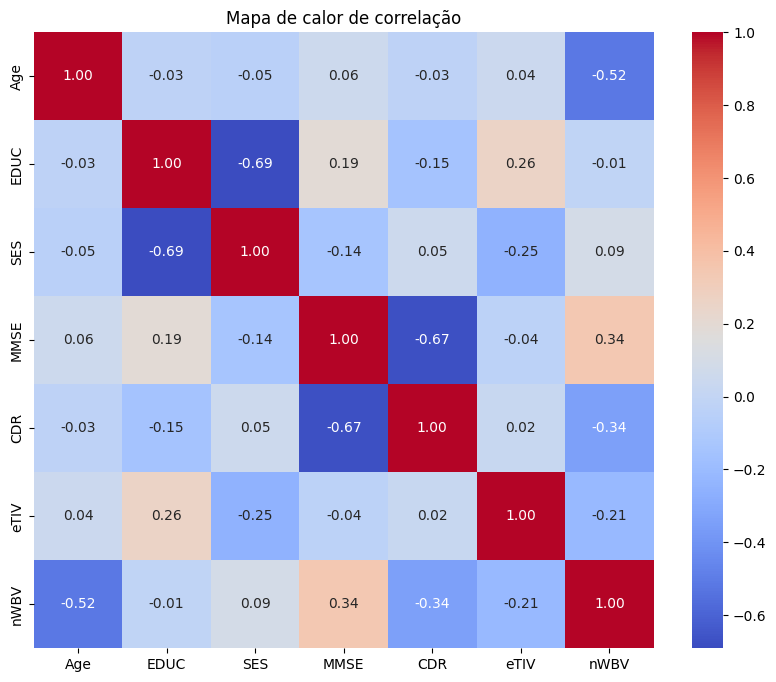

In [196]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Mapa de calor de correlação')
plt.show()

VALORES RELACIONADOS: 

- "CDR" e "MMSE" (quanto maior o grau de demência, menor o escore no teste MMSE)
- "CDR" e "nWBV" (quanto maior o grau de demência, menor o volume do cérebro)
- "Age" e "nWBV" (quanto maior a idade, menor o volume do cérebro)

In [197]:
df.drop('CDR', inplace=True, axis=1)

Como o "CDR" é uma medida de "nível de demência", quando seu valor é zero, a variável "Group" mostra "Nondemented"; já quando o valor é maior que zero, a variável "Group" mostra "Demented". Sendo assim, como o "Group" é a variável de resposta que queremos (target), e ela está relacionada nesse nível com o "CDR", precisamos não incluir "CDR" como parte das variáveis "pergunta" (features).

VARIÁVEIS FEATURE (X): Age, EDUC, MMSE, nWBV, eTIV, SES*, Gender

VARIÁVEL TARGET (y): Group